Selected points: 1624


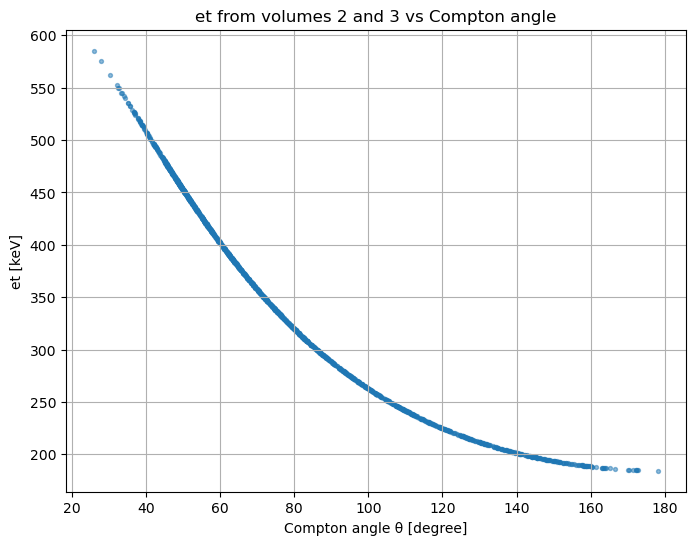

In [1]:
import ROOT
import math
import numpy as np
import matplotlib.pyplot as plt

root_file = "sucrose.root"
tree_name = "t"

volume_ids = [2, 3]     # volume 2 and volume 3
pdg_code = 22           # gamma
compton_code = 2013

E0 = 662.0              # keV
me = 511.0              # keV

f = ROOT.TFile.Open(root_file)
t = f.Get(tree_name)

theta_list = []
et_list = []

for entry in t:

    n = min(len(entry.pdg), len(entry.vlm), len(entry.et), len(entry.pro))

    for i in range(n):

        if int(entry.pdg[i]) != pdg_code:
            continue

        if int(entry.pro[i]) != compton_code:
            continue

        if int(entry.vlm[i]) not in volume_ids:
            continue

        Es = float(entry.et[i])   # gamma energy from volume 2 or 3

        if Es <= 0 or Es >= E0:
            continue

        # Compton angle from scattered gamma energy
        cos_theta = 1.0 - me * (1.0 / Es - 1.0 / E0)

        if cos_theta < -1.0 or cos_theta > 1.0:
            continue

        theta_deg = math.degrees(math.acos(cos_theta))

        theta_list.append(theta_deg)
        et_list.append(Es)

f.Close()

theta = np.array(theta_list)
et = np.array(et_list)

print("Selected points:", len(theta))

plt.figure(figsize=(8, 6))
plt.scatter(theta, et, s=8, alpha=0.5)

plt.xlabel("Compton angle θ [degree]")
plt.ylabel("et [keV]")
plt.title("et from volumes 2 and 3 vs Compton angle")
plt.grid(True)
plt.show()